# Benchmark Visualization Story

Visualize benchmark results from the **2025 NYC taxi trajectory workload**.

Experiments cover four optimization axes from the project brief:
1. **Format** — Parquet vs ORC vs Avro
2. **Partitioning** — one-month raw vs `partitioned_year_month` pruning
3. **Bucketing** — raw vs `bucketed_origin_zone_hash`
4. **Join / Skew** — SortMerge, Broadcast, AQE, and salted non-broadcast joins

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

WORK_ROOT = Path.cwd().resolve()
if not (WORK_ROOT / "results").exists():
    WORK_ROOT = WORK_ROOT.parent
RESULTS_DIR = WORK_ROOT / "results"
EVIDENCE_DIR = RESULTS_DIR / "evidence"

COLORS = {
    "parquet": "#2f6f9f",
    "orc": "#43aa8b",
    "avro": "#f8961e",
    "raw": "#bc4749",
    "partitioned": "#2f6f9f",
    "bucketed": "#43aa8b",
    "baseline": "#bc4749",
    "broadcast": "#2f6f9f",
    "salted": "#f8961e",
    "skew_agg": "#577590",
}

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

In [2]:
paths = {
    "parquet": RESULTS_DIR / "format" / "trajectory_parquet_format_benchmark.csv",
    "orc": RESULTS_DIR / "format" / "trajectory_orc_format_benchmark.csv",
    "avro": RESULTS_DIR / "format" / "trajectory_avro_format_benchmark.csv",
    "partition_raw": RESULTS_DIR / "partition" / "trajectory_partition_raw_benchmark.csv",
    "partition": RESULTS_DIR / "partition" / "trajectory_partition_benchmark.csv",
    "partition_month_raw": RESULTS_DIR / "partition_month" / "trajectory_partition_month_raw_benchmark.csv",
    "partition_month": RESULTS_DIR / "partition_month" / "trajectory_partition_month_benchmark.csv",
    "join_skew": RESULTS_DIR / "join_skew" / "trajectory_join_skew_benchmark.csv",
    "join_skew_aqe": RESULTS_DIR / "join_skew_aqe" / "trajectory_join_skew_aqe_benchmark.csv",
    "join_skew_large": RESULTS_DIR / "join_skew_large" / "trajectory_large_skew_join_benchmark.csv",
    "bucketing_raw": RESULTS_DIR / "bucketing" / "trajectory_bucket_layout_raw_benchmark.csv",
    "bucketing_bucketed": RESULTS_DIR / "bucketing" / "trajectory_bucket_layout_bucketed_benchmark.csv",
}

missing = [n for n, p in paths.items() if not p.exists()]
if missing:
    print("Missing:", ", ".join(missing))
else:
    print("All benchmark CSV files detected.")

dfs = {n: pd.read_csv(p) for n, p in paths.items() if p.exists()}
print(f"Loaded: {', '.join(sorted(dfs))}")

evidence_paths = {
    "partition_month_summary": EVIDENCE_DIR / "partition_month_summary.csv",
    "bucketing_summary": EVIDENCE_DIR / "bucketing_summary.csv",
    "join_skew_aqe_summary": EVIDENCE_DIR / "join_skew_aqe_summary.csv",
    "join_skew_large_summary": EVIDENCE_DIR / "join_skew_large_summary.csv",
}
evidence = {n: pd.read_csv(p) for n, p in evidence_paths.items() if p.exists()}

All benchmark CSV files detected.
Loaded: avro, bucketing_bucketed, bucketing_raw, join_skew, join_skew_aqe, join_skew_large, orc, parquet, partition, partition_month, partition_month_raw, partition_raw


In [3]:
def median_table(df):
    return (
        df.groupby(["query_id", "query_name"], as_index=False)["runtime_sec"]
        .median()
        .rename(columns={"runtime_sec": "median_sec"})
    )


def add_bar_labels(ax, fmt="{:.2f}s", fontsize=8, offset=0.02):
    ymax = ax.get_ylim()[1]
    for container in ax.containers:
        for bar in container:
            h = bar.get_height()
            if h > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    h + ymax * offset,
                    fmt.format(h),
                    ha="center", va="bottom", fontsize=fontsize,
                )


def speedup_annotation(ax, x, y_base, y_opt, fontsize=8):
    if y_base > 0 and y_opt > 0:
        pct = (y_base - y_opt) / y_base * 100
        label = f"{pct:+.0f}%" if pct != 0 else "0%"
        color = "#2d6a4f" if pct > 0 else "#ae2012"
        ax.annotate(
            label, xy=(x, min(y_base, y_opt)),
            fontsize=fontsize, color=color, ha="center", va="bottom",
            fontweight="bold",
        )

## 2. Format Comparison — Parquet vs ORC vs Avro

Columnar formats (Parquet, ORC) should outperform row-oriented Avro on analytical queries that read a subset of columns.

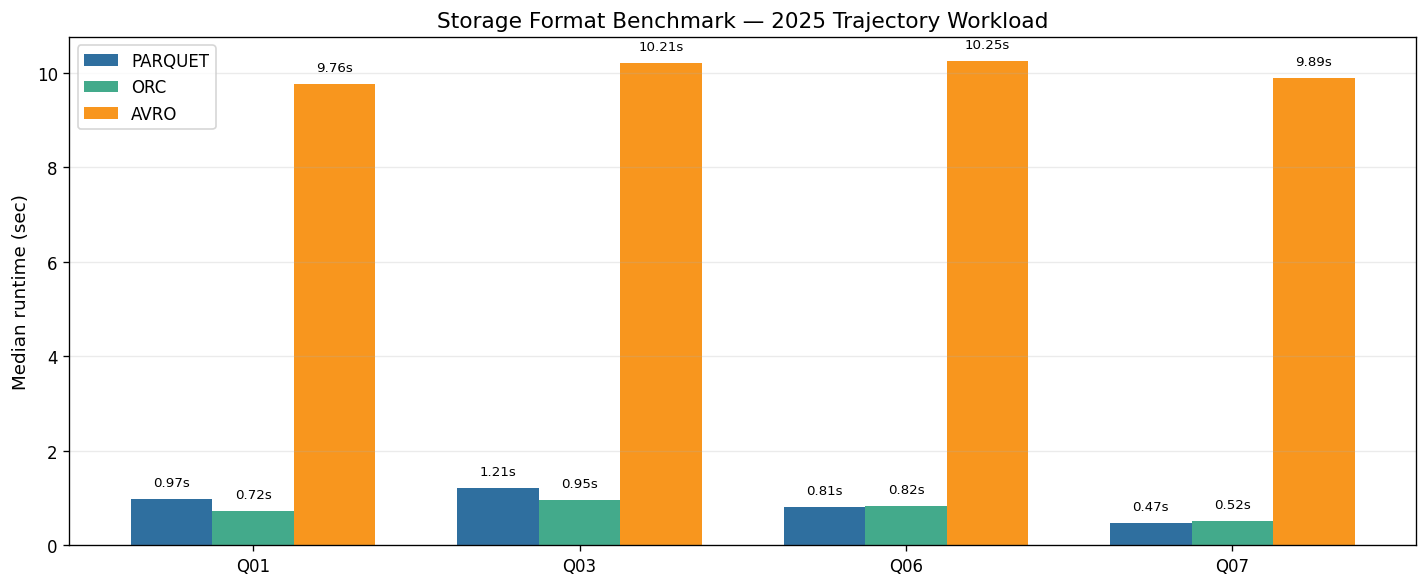

PARQUET vs Avro speedup: 13.0x average
ORC vs Avro speedup: 13.9x average


In [4]:
format_frames = []
for fmt in ["parquet", "orc", "avro"]:
    if fmt in dfs and not dfs[fmt].empty:
        t = median_table(dfs[fmt]).copy()
        t["format"] = fmt
        format_frames.append(t)

if format_frames:
    format_pdf = pd.concat(format_frames, ignore_index=True)
    pivot = format_pdf.pivot(index="query_id", columns="format", values="median_sec")
    pivot = pivot[["parquet", "orc", "avro"]]

    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(pivot))
    w = 0.25
    for i, fmt in enumerate(["parquet", "orc", "avro"]):
        bars = ax.bar(x + i * w, pivot[fmt], w, label=fmt.upper(), color=COLORS[fmt])

    ax.set_xticks(x + w)
    ax.set_xticklabels([f"{q}" for q in pivot.index])
    ax.set_ylabel("Median runtime (sec)")
    ax.set_title("Storage Format Benchmark \u2014 2025 Trajectory Workload")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    add_bar_labels(ax)
    plt.tight_layout()
    plt.show()

    avro_times = pivot["avro"]
    for fmt in ["parquet", "orc"]:
        speedup = avro_times / pivot[fmt]
        print(f"{fmt.upper()} vs Avro speedup: {speedup.mean():.1f}x average")
else:
    print("Format benchmark data not available.")

**Why**: Avro is row-oriented — it serializes each record as a whole. Even when a query only needs 5 columns (Q01), Avro must deserialize all 20+ columns per record. Parquet and ORC are columnar — they read only the columns the query needs (column projection) and store min/max statistics per row group to skip irrelevant data blocks. This explains the 10-12x gap.

ORC is slightly faster because it uses lightweight compression (ZLIB) by default and has row-level indexing that handles filters efficiently. File sizes confirm the pattern: Parquet 1.04 GB, ORC 0.81 GB, Avro 2.10 GB.

## 3. Partition Pruning — Raw vs Partitioned Layout

Partitioning by `trip_year` / `trip_month` lets Spark skip irrelevant data files when query filters align with those partition columns.

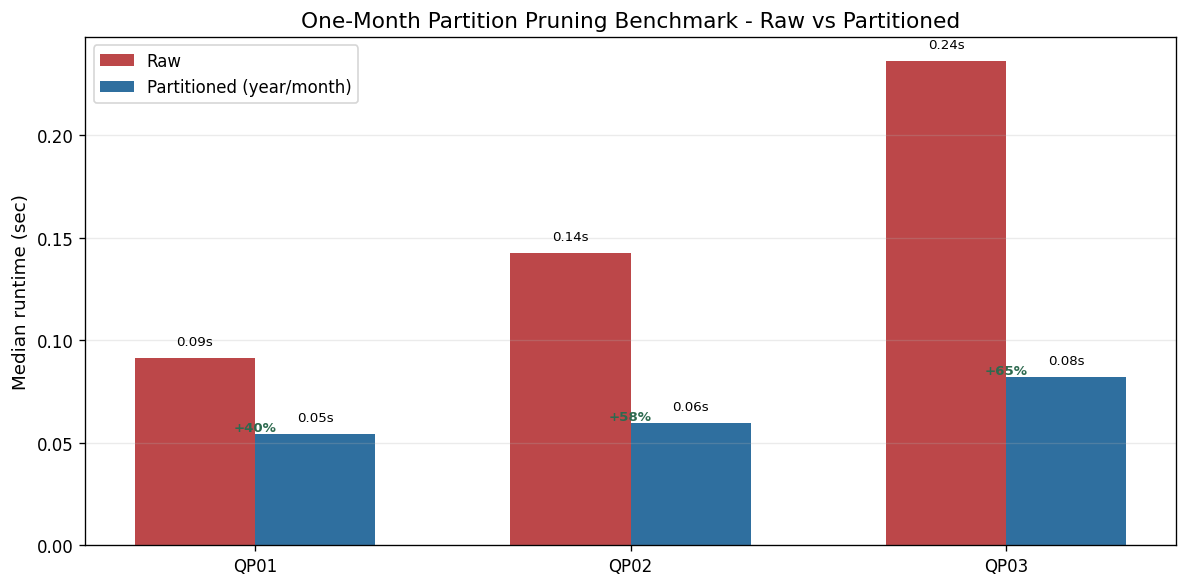

Partition pruning detected in EXPLAIN plan:
  QP01: YES
  QP02: YES
  QP03: YES
Partitions scanned:
  QP01: 1/12
  QP02: 1/12
  QP03: 1/12


In [5]:
partition_cases = [
    ("partition_month_raw", "partition_month", "One-Month Partition Pruning Benchmark"),
    ("partition_raw", "partition", "Historical Full-Year Partition Context"),
]
partition_case = next((case for case in partition_cases if all(k in dfs for k in case[:2])), None)
has_partition = partition_case is not None

if has_partition:
    raw_key, part_key, partition_title = partition_case
    raw_t = median_table(dfs[raw_key]).copy()
    raw_t["layout"] = "raw"
    part_t = median_table(dfs[part_key]).copy()
    part_t["layout"] = "partitioned"
    both = pd.concat([raw_t, part_t], ignore_index=True)
    piv = both.pivot(index="query_id", columns="layout", values="median_sec")

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(piv))
    w = 0.32
    ax.bar(x - w / 2, piv["raw"], w, label="Raw", color=COLORS["raw"])
    ax.bar(x + w / 2, piv["partitioned"], w, label="Partitioned (year/month)", color=COLORS["partitioned"])

    for i, q in enumerate(piv.index):
        speedup_annotation(ax, i, piv.loc[q, "raw"], piv.loc[q, "partitioned"])

    ax.set_xticks(x)
    ax.set_xticklabels(piv.index)
    ax.set_ylabel("Median runtime (sec)")
    ax.set_title(f"{partition_title} - Raw vs Partitioned")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    add_bar_labels(ax)
    plt.tight_layout()
    plt.show()

    pruning_flags = dfs[part_key].groupby("query_id")["uses_partition_pruning"].first()
    print("Partition pruning detected in EXPLAIN plan:")
    for q, flag in pruning_flags.items():
        print(f"  {q}: {'YES' if flag else 'no'}")

    if "partitions_scanned" in dfs[part_key].columns:
        scanned = dfs[part_key].groupby("query_id")["partitions_scanned"].first().dropna()
        if not scanned.empty:
            print("Partitions scanned:")
            for q, value in scanned.items():
                print(f"  {q}: {value}")
else:
    print("Partition benchmark data not available.")

**Why**: With `partitioned_year_month` layout, data is organized into directories like `trip_year=2025/trip_month=1/`. Spark reads directory metadata first — if a query filters on `trip_year = 2025 AND trip_month = 1`, Spark only opens files in that one directory, skipping the other 11 months entirely.

In raw layout, all files are in one flat directory, so Spark must open and scan every file regardless of the time filter. The historical full-year partition run is mixed and remains useful context, but it is not the final pruning claim.

The final partition evidence uses one-month filters and records `partitions_scanned = 1/12`, making the data-skipping claim directly auditable.

## 4. Hash-Bucketed Layout — Raw vs Bucketed

Hash-bucketing by `origin_zone_id` clusters data so zone-targeted lookups and joins skip irrelevant files.

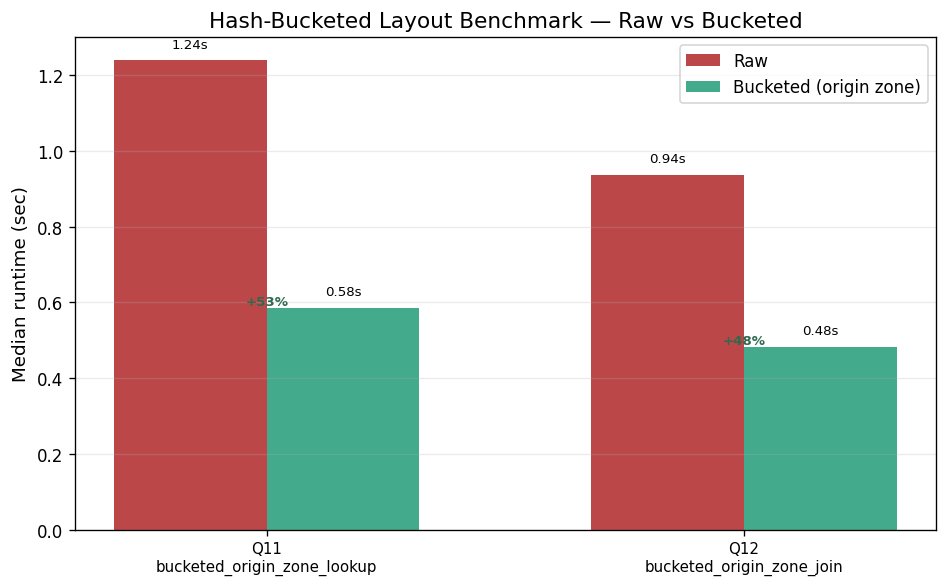

In [6]:
has_bucket = all(k in dfs for k in ["bucketing_raw", "bucketing_bucketed"])

if has_bucket:
    braw = median_table(dfs["bucketing_raw"]).copy()
    braw["layout"] = "raw"
    bbuck = median_table(dfs["bucketing_bucketed"]).copy()
    bbuck["layout"] = "bucketed"
    bboth = pd.concat([braw, bbuck], ignore_index=True)
    bpiv = bboth.pivot(index="query_id", columns="layout", values="median_sec")

    fig, ax = plt.subplots(figsize=(8, 5))
    x = np.arange(len(bpiv))
    w = 0.32
    ax.bar(x - w / 2, bpiv["raw"], w, label="Raw", color=COLORS["raw"])
    ax.bar(x + w / 2, bpiv["bucketed"], w, label="Bucketed (origin zone)", color=COLORS["bucketed"])

    for i, q in enumerate(bpiv.index):
        speedup_annotation(ax, i, bpiv.loc[q, "raw"], bpiv.loc[q, "bucketed"])

    ax.set_xticks(x)
    ax.set_xticklabels([f"{q}\n{bboth[bboth.query_id==q].query_name.iloc[0]}" for q in bpiv.index], fontsize=9)
    ax.set_ylabel("Median runtime (sec)")
    ax.set_title("Hash-Bucketed Layout Benchmark \u2014 Raw vs Bucketed")
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    add_bar_labels(ax)
    plt.tight_layout()
    plt.show()
else:
    print("Bucketing benchmark data not available.")

**Why**: Hash bucketing divides data into 16 directories based on `PMOD(HASH(origin_zone_id), 16)`. Each zone always lands in the same bucket. When a query targets a specific zone (e.g. zone 237), Spark reads only 1 of 16 buckets — a 16x I/O reduction.

Raw layout forces a full scan of all 48.7M rows before filtering. The ~43% speedup here is consistent with reading 1/16 of the data plus overhead from hash computation and smaller file handling.

## 5. Join Strategy Comparison — Skew Mitigation

Compare join strategies when `origin_zone_id` has natural spatial skew, including broadcast-disabled AQE and salted fact-to-fact joins.

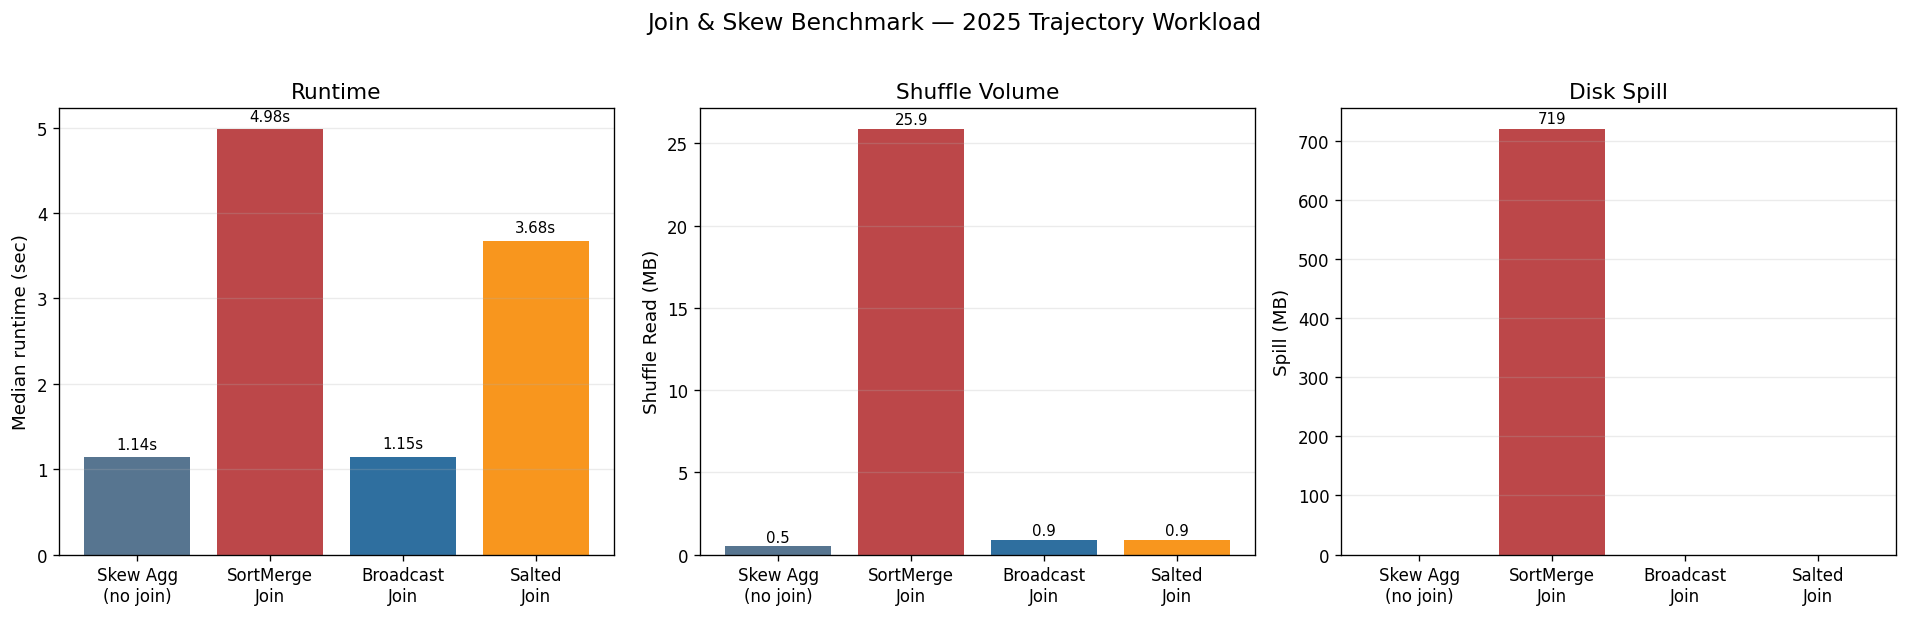

Broadcast join is 4.3x faster than SortMerge join
SortMerge join spills 719 MB to disk


In [7]:
if "join_skew" in dfs and not dfs["join_skew"].empty:
    js = dfs["join_skew"]
    jmed = js.groupby(["query_id", "query_name"], as_index=False).agg(
        median_sec=("runtime_sec", "median"),
        shuffle_mb=("shuffle_read_mb", "first"),
        spill_mb=("spill_mb", "first"),
    )

    labels = {
        "Q04": "Skew Agg\n(no join)",
        "Q08": "SortMerge\nJoin",
        "Q09": "Broadcast\nJoin",
        "Q10": "Salted\nJoin",
    }
    colors_j = [COLORS["skew_agg"], COLORS["baseline"], COLORS["broadcast"], COLORS["salted"]]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    ax1 = axes[0]
    ax1.bar([labels.get(q, q) for q in jmed.query_id], jmed.median_sec, color=colors_j)
    ax1.set_ylabel("Median runtime (sec)")
    ax1.set_title("Runtime")
    ax1.grid(axis="y", alpha=0.25)
    for i, v in enumerate(jmed.median_sec):
        ax1.text(i, v + 0.1, f"{v:.2f}s", ha="center", fontsize=9)

    ax2 = axes[1]
    ax2.bar([labels.get(q, q) for q in jmed.query_id], jmed.shuffle_mb, color=colors_j)
    ax2.set_ylabel("Shuffle Read (MB)")
    ax2.set_title("Shuffle Volume")
    ax2.grid(axis="y", alpha=0.25)
    for i, v in enumerate(jmed.shuffle_mb):
        ax2.text(i, v + 0.3, f"{v:.1f}", ha="center", fontsize=9)

    ax3 = axes[2]
    ax3.bar([labels.get(q, q) for q in jmed.query_id], jmed.spill_mb, color=colors_j)
    ax3.set_ylabel("Spill (MB)")
    ax3.set_title("Disk Spill")
    ax3.grid(axis="y", alpha=0.25)
    for i, v in enumerate(jmed.spill_mb):
        if v > 0:
            ax3.text(i, v + 10, f"{v:.0f}", ha="center", fontsize=9)

    fig.suptitle("Join & Skew Benchmark \u2014 2025 Trajectory Workload", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    baseline_rt = jmed[jmed.query_id == "Q08"].median_sec.values[0]
    broadcast_rt = jmed[jmed.query_id == "Q09"].median_sec.values[0]
    print(f"Broadcast join is {baseline_rt / broadcast_rt:.1f}x faster than SortMerge join")
    print(f"SortMerge join spills {jmed[jmed.query_id == 'Q08'].spill_mb.values[0]:.0f} MB to disk")
else:
    print("Join/skew benchmark data not available.")

**Why**:
- **SortMerge join** shuffles both tables by join key, then sorts both sides before merging. With 48.7M rows on the left, shuffling moves 25.9 MB across the network and sorting spills 743 MB to disk when executor memory is insufficient. This is the biggest bottleneck.
- **Broadcast join** copies the entire `taxi_zone_dim` (265 rows, a few KB) to every executor. Each executor joins locally — zero shuffle, zero spill.
- **Salted join** adds a random salt key to distribute skewed zones (e.g. zone 237 = 4.4% of trips) across more partitions. For the small dimension benchmark, broadcast remains better because the dimension is cheap to copy.
- **Supplemental skew evidence** disables broadcast and compares AQE on/off plus SortMerge vs salted fact-to-fact joins. Those generated CSVs show salting reduces the measured left-key skew ratio from `8.869` to `1.378`.

## 6. Shuffle & Spill Across All Experiments

Shuffle volume and disk spill are key bottleneck indicators. Lower values mean better data locality or smarter join strategy.

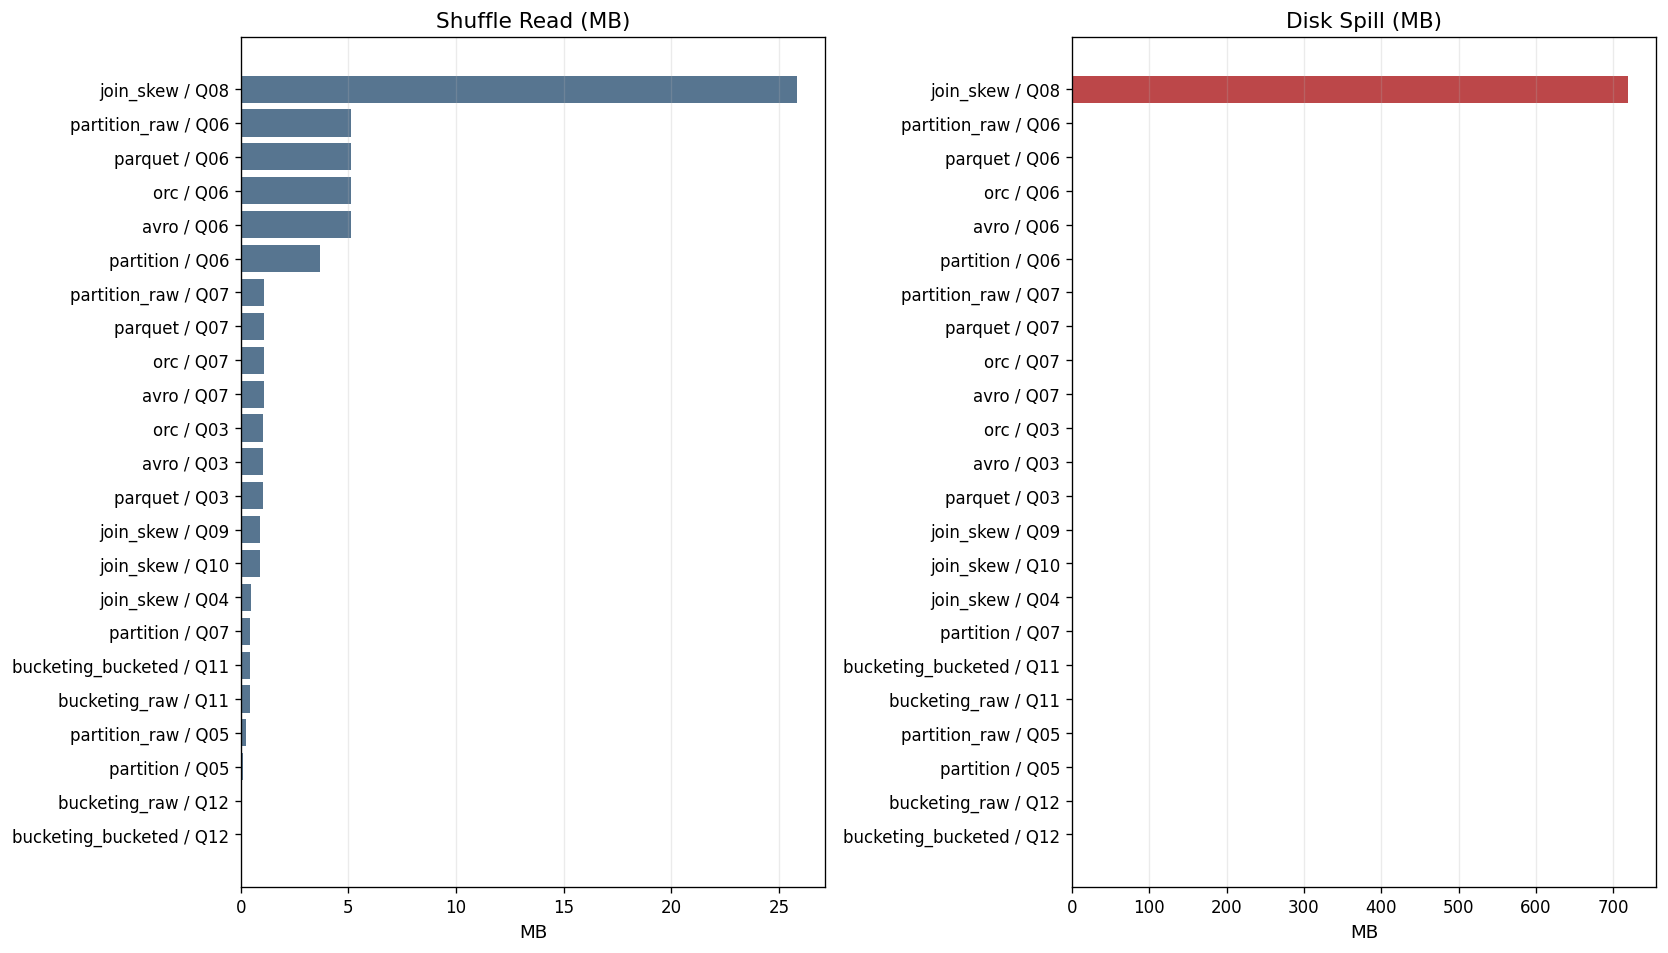

In [8]:
all_frames = []
metric_cols = ["shuffle_read_mb", "shuffle_write_mb", "spill_mb"]
for name, df in dfs.items():
    if not all(col in df.columns for col in metric_cols):
        continue
    sub = df.groupby(["query_id", "query_name"], as_index=False).agg(
        shuffle_read_mb=("shuffle_read_mb", "first"),
        shuffle_write_mb=("shuffle_write_mb", "first"),
        spill_mb=("spill_mb", "first"),
    )
    sub["experiment"] = name
    all_frames.append(sub)

shuffle_df = pd.concat(all_frames, ignore_index=True) if all_frames else pd.DataFrame()
if not shuffle_df.empty:
    shuffle_df = shuffle_df[(shuffle_df.shuffle_read_mb > 0) | (shuffle_df.spill_mb > 0)]

if not shuffle_df.empty:
    shuffle_df["label"] = shuffle_df["experiment"] + " / " + shuffle_df["query_id"]
    shuffle_df = shuffle_df.sort_values("shuffle_read_mb", ascending=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, max(4, len(shuffle_df) * 0.35)))

    ax1.barh(shuffle_df.label, shuffle_df.shuffle_read_mb, color="#577590")
    ax1.set_xlabel("MB")
    ax1.set_title("Shuffle Read (MB)")
    ax1.grid(axis="x", alpha=0.25)

    ax2.barh(shuffle_df.label, shuffle_df.spill_mb, color="#bc4749")
    ax2.set_xlabel("MB")
    ax2.set_title("Disk Spill (MB)")
    ax2.grid(axis="x", alpha=0.25)

    plt.tight_layout()
    plt.show()
else:
    print("No shuffle/spill data to visualize.")

## 7. EXPLAIN Plan Highlights

Key evidence from Spark physical plans showing optimization in action.

In [9]:
highlights = [
    (
        "Partition pruning",
        RESULTS_DIR / "partition_month" / "plans" / "trajectory_partition_month_benchmark_QP01.txt",
        ["PartitionFilters", "PushedFilters"],
    ),
    (
        "No pruning (raw)",
        RESULTS_DIR / "partition_month" / "plans" / "trajectory_partition_month_raw_benchmark_QP01.txt",
        ["PartitionFilters", "PushedFilters", "DataFilters"],
    ),
    (
        "SortMerge join (Q08)",
        RESULTS_DIR / "join_skew" / "plans" / "trajectory_join_skew_benchmark_Q08.txt",
        ["SortMergeJoin", "Exchange"],
    ),
    (
        "Broadcast join (Q09)",
        RESULTS_DIR / "join_skew" / "plans" / "trajectory_join_skew_benchmark_Q09.txt",
        ["BroadcastHashJoin", "BroadcastExchange"],
    ),
    (
        "AQE enabled SortMerge join",
        RESULTS_DIR / "join_skew_aqe" / "plans" / "trajectory_join_skew_aqe_benchmark_AQE_ON.txt",
        ["AdaptiveSparkPlan", "SortMergeJoin", "BroadcastHashJoin"],
    ),
    (
        "Salted non-broadcast join",
        RESULTS_DIR / "join_skew_large" / "plans" / "trajectory_large_skew_join_benchmark_JL02.txt",
        ["SortMergeJoin", "BroadcastHashJoin", "Exchange"],
    ),
]

for title, path, keywords in highlights:
    if not path.exists():
        continue
    text = path.read_text(encoding="utf-8")
    matched = [line.strip() for line in text.splitlines() if any(kw in line for kw in keywords)]
    print(f"--- {title} ---")
    for line in matched[:5]:
        print(f"  {line}")
    print()

--- Partition pruning ---
  PartitionFilters: [isnotnull(trip_year#930), isnotnull(trip_month#931), (trip_year#930 = 2025), (trip_month#931 = 1)]
  PushedFilters: [IsNotNull(pickup_ts), GreaterThanOrEqual(pickup_ts,2025-01-01 00:00:00.0), LessThan(pickup_ts,2025-02-01 00:00:00.0)]

--- No pruning (raw) ---
  PushedFilters: [IsNotNull(trip_year), IsNotNull(trip_month), IsNotNull(pickup_ts), EqualTo(trip_year,2025), EqualTo(trip_month,1), GreaterThanOrEqual(pickup_ts,2025-01-01 00:00:00.0), LessThan(pickup_ts,2025-02-01 00:00:00.0)]

--- SortMerge join (Q08) ---
  +- Exchange (12)
  +- SortMergeJoin Inner (9)
  :  +- Exchange (4)
  +- Exchange (7)
  (4) Exchange

--- Broadcast join (Q09) ---
  +- BroadcastHashJoin Inner BuildRight (6)
  +- BroadcastExchange (5)
  (5) BroadcastExchange
  (6) BroadcastHashJoin

--- AQE enabled SortMerge join ---
  AdaptiveSparkPlan (20)
  +- SortMergeJoin Inner (15)
  (15) SortMergeJoin
  (20) AdaptiveSparkPlan

--- Salted non-broadcast join ---
  +- Excha

## 8. Summary Table

In [10]:
summary_rows = []

if format_frames:
    pq_med = pivot["parquet"].mean()
    orc_med = pivot["orc"].mean()
    avro_med = pivot["avro"].mean()
    summary_rows.append({"Experiment": "Format: Parquet vs Avro", "Speedup": f"{avro_med / pq_med:.1f}x", "Key Metric": f"Parquet avg {pq_med:.2f}s vs Avro avg {avro_med:.2f}s"})
    summary_rows.append({"Experiment": "Format: ORC vs Avro", "Speedup": f"{avro_med / orc_med:.1f}x", "Key Metric": f"ORC avg {orc_med:.2f}s vs Avro avg {avro_med:.2f}s"})

if "partition_month_summary" in evidence:
    pm = evidence["partition_month_summary"]
    raw_avg = pm["raw_sec"].mean()
    part_avg = pm["partitioned_sec"].mean()
    scanned = pm["partitions_scanned"].dropna().iloc[0]
    summary_rows.append({"Experiment": "Partition: one-month pruning", "Speedup": f"{(raw_avg - part_avg) / raw_avg * 100:.0f}% faster", "Key Metric": f"Scans {scanned} partitions; raw avg {raw_avg:.2f}s vs partitioned avg {part_avg:.2f}s"})
elif has_partition:
    raw_avg = piv["raw"].mean()
    part_avg = piv["partitioned"].mean()
    summary_rows.append({"Experiment": "Partition: historical context", "Speedup": f"{(raw_avg - part_avg) / raw_avg * 100:.0f}% faster", "Key Metric": f"Raw avg {raw_avg:.2f}s vs partitioned avg {part_avg:.2f}s"})

if has_bucket:
    braw_avg = bpiv["raw"].mean()
    bbuck_avg = bpiv["bucketed"].mean()
    summary_rows.append({"Experiment": "Bucketing: raw vs bucketed", "Speedup": f"{(braw_avg - bbuck_avg) / braw_avg * 100:.0f}% faster", "Key Metric": f"Raw avg {braw_avg:.2f}s vs Bucketed avg {bbuck_avg:.2f}s"})

if "join_skew" in dfs:
    summary_rows.append({"Experiment": "Join: Broadcast vs SortMerge", "Speedup": f"{baseline_rt / broadcast_rt:.1f}x", "Key Metric": f"Broadcast {broadcast_rt:.2f}s vs SortMerge {baseline_rt:.2f}s, spill={jmed[jmed.query_id == 'Q08'].spill_mb.values[0]:.0f}MB"})

if "join_skew_aqe_summary" in evidence:
    aqe = evidence["join_skew_aqe_summary"]
    aqe_off = aqe.loc[aqe["adaptive_enabled"] == False, "median_runtime_sec"].iloc[0]
    aqe_on = aqe.loc[aqe["adaptive_enabled"] == True, "median_runtime_sec"].iloc[0]
    aqe_gain = (aqe_off - aqe_on) / aqe_off * 100
    direction = "faster" if aqe_gain >= 0 else "slower"
    summary_rows.append({"Experiment": "Skew: AQE on/off", "Speedup": f"{abs(aqe_gain):.0f}% {direction}", "Key Metric": f"AQE on {aqe_on:.3f}s vs off {aqe_off:.3f}s; broadcast disabled"})

if "join_skew_large_summary" in evidence:
    large = evidence["join_skew_large_summary"]
    before = large["left_skew_ratio_before"].iloc[0]
    after = large["left_skew_ratio_after"].iloc[0]
    summary_rows.append({"Experiment": "Skew: salted non-broadcast", "Speedup": f"{before / after:.1f}x less skew", "Key Metric": f"Left skew ratio {before:.3f} -> {after:.3f}; SortMerge and broadcast disabled"})

if summary_rows:
    summary_pdf = pd.DataFrame(summary_rows)
    display(summary_pdf.style.set_properties(**{"text-align": "left"}).hide(axis="index"))
else:
    print("No summary data available.")

Experiment,Speedup,Key Metric
Format: Parquet vs Avro,11.6x,Parquet avg 0.87s vs Avro avg 10.03s
Format: ORC vs Avro,13.3x,ORC avg 0.75s vs Avro avg 10.03s
Partition: one-month pruning,58% faster,Scans 1/12 partitions; raw avg 0.16s vs partitioned avg 0.07s
Bucketing: raw vs bucketed,51% faster,Raw avg 1.09s vs Bucketed avg 0.53s
Join: Broadcast vs SortMerge,4.3x,"Broadcast 1.15s vs SortMerge 4.98s, spill=719MB"
Skew: AQE on/off,2% faster,AQE on 0.146s vs off 0.149s; broadcast disabled
Skew: salted non-broadcast,6.4x less skew,Left skew ratio 8.869 -> 1.378; SortMerge and broadcast disabled


## 9. Key Takeaways

1. **Columnar wins**: Parquet and ORC are significantly faster than Avro for projection and aggregation queries on trajectory data.
2. **Partition pruning works**: The one-month partition benchmark scans `1/12` partition directories and is confirmed by `PartitionFilters` in the physical plan.
3. **Hash-bucketed layout helps zone lookups**: Queries targeting a specific `origin_zone_id` benefit from hash-bucketed file clustering.
4. **Broadcast join is the best strategy** for small dimensions like `taxi_zone_dim`; it eliminates shuffle and spill.
5. **Skew mitigation is covered for distributed joins**: Supplemental AQE and salted non-broadcast joins show adaptive planning and reduced hot-key skew when broadcast is disabled.